<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab6/L6_Colab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6.1 Database & Visualization - MySQL Hands-on Activities

## Learning Goals

Students will be able to:

1. Utilize MySQL workbench to create a database table.
2. Write SQL statements to modify, edit, and extract data from a table

## 1.1 Introduction

The topic of Lab6 is SQL database. We will practice using SQL database, specifically MySQL, to collect IIoT data in this lab. Please note that even if SQL is the relational database, we won’t go on a relational database structure because it is out of the scope of this course. In this lab, however, you will learn the basic syntax of SQL and Python programming to aggregate sensor data to MySQL database. Through hands-on activities, you will perform 1) creating a database table, 2) inserting data to the table using SQL, and 3) Python programming to collect data to the database. At the end of this lab, you will make your Raspberry Pi transmit data from sensors (DHT11 and ADXL345) to the database. To focus on SQL in this lab, let’s set aside the use of MTConnect.

## 1.2 Creating a database table


Let’s start with creating a database table to store data on MySQL server. The MySQL server domain and the port number information for this lab are below.
* DNS: mepotrb16.ecn.purdue.edu
* Port: 3306

The TA made an account for each of you. The account name rule is your ‘firstnamelastname’ based on
Brightspace, for example, John Doe’s account name for ME597 MySQL server is ‘johndoe’. And TA will let you know the password of your account.
<br></br>
Let’s connect MySQL server using MySQL Workbench you installed on laptop in the prelab. Please follow the steps below.

1.	Run *‘MySQL Workbench’* on laptop.
2.	Click ‘+’ symbol next to *‘MySQL Connections’*.

  a. *‘Setup New Connection’* window pops up.

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab6_img1.png?raw=true" width="70%">

3.	Put information on *‘Setup New Connection’* below and then click ‘OK’.

  a.	‘Connection Name’: ME597

  b.	‘Hostname’: mepotrb16.ecn.purdue.edu

  c.	‘Port’: 3306

  d.	‘Username’: firstnamelastname

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab6_img2.png?raw=true" width="70%">
  
4.	Click ‘ME597’ connection on ‘MySQL Workbench’.
5.	Put your password on *‘Connection to MySQL Server’* window.
6.	Click *‘Save password in vault’* check box.
7.	Click *‘OK’*

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab6_img3.png?raw=true" width="70%">




Now, you made a connection to the MySQL server. The next is to create a table. Follow the steps below.

1.	Click ‘Schemas’ tab on the left middle side.

  a.	Schema in a SQL database stands for a list of logical structures of data.

  b.	In the ‘Navigator’ section, you will see database.

2.	Click dropdown button (▼) database on *‘Navigator’* section. (Database name may different)
3.	Right click on *‘Tables’* under database.
4.	Click *‘Create Tables…’* on the right click menu.

  a.	You will see a new tab for creating a table.

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S24_update/lab6_create_table.png?raw=true" width="70%">

5.	Make table name as ‘firstnamelastname_lab6’.

  a.	E.g., ‘Table Name’: johndoe_lab6

6. Create columns as the table and capture below.

<table width="50%">
<thead>
  <tr>
    <th>Column Name</th>
    <th>Datatype</th>
    <th>Option (Column flag)</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td>id</td>
    <td>INT</td>
    <td>PK, NN, AI</td>
  </tr>
  <tr>
    <td>timestamp</td>
    <td>TIMESTAMP(1)</td>
    <td></td>
  </tr>
  <tr>
    <td>sensor</td>
    <td>VARCHAR(45)</td>
    <td>NN</td>
  </tr>
  <tr>
    <td>measurement</td>
    <td>VARCHAR(45)</td>
    <td>NN</td>
  </tr>
  <tr>
    <td>value</td>
    <td>TINYTEXT</td>
    <td>NN</td>
  </tr>
</tbody>
</table>


  a. Brief descriptions of column flags are below.
  * PK – Primary Key: It can be used to make the column as a primary key.
  * NN – NOT NULL: It is used to enforce the column that it will not insert a NULL value.
  * BIN – Binary: It is used to store data as a binary string.
  * UN – Unsigned: It is used to store an only positive value started from 0.
  * UQ – Unique: It can be used to enforce the column to insert only unique value for a specific column.
  * ZF – Zero Filled: It makes stored values have specific size by filling 0.
  * G – Generated column
  * AI – Auto Increment

7.	Click *‘Apply’*.

  a. ‘Apply SQL Script to Database’ window pops up.
  
  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S24_update/lab6_create_data_info.png?raw=true" width="70%">

8.	Click *‘Apply’* on *‘Apply SQL Script to Database’* window.
9.	Click *‘Finish’* on *‘Apply SQL Script to Database’* window.
  
  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S24_update/lab6_apply_SQL_script.png?raw=true" width="100%">

10.	If you click the dropdown button (▼) next to ‘Tables’ on ‘Navigator’ section, you will see the created table as below.
You should create table under the database

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S24_update/lab6_created_table.png?raw=true" width="30%">


You are all set to store data. To see your table, the easiest way on ‘MySQL Workbench’ is that right click your table on ‘Navigator’ and then click ‘Select Rows – Limit 1000’ as Figure 1 (left). Because you do not have any data in the table yet, all column data are NULL as Figure 1 (right). And you can see the executed SQL query on the upper side of your table tab as figure 1 (right).

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S24_update/lab6_created_table2.png?raw=true" width="90%">

*Figure 1 Select rows of created table (left) and executed SELECT statement to check data*

### Task 1.1

After creating and checking your table, capture the result as Figure 1 (right) and attach it to the report.

---

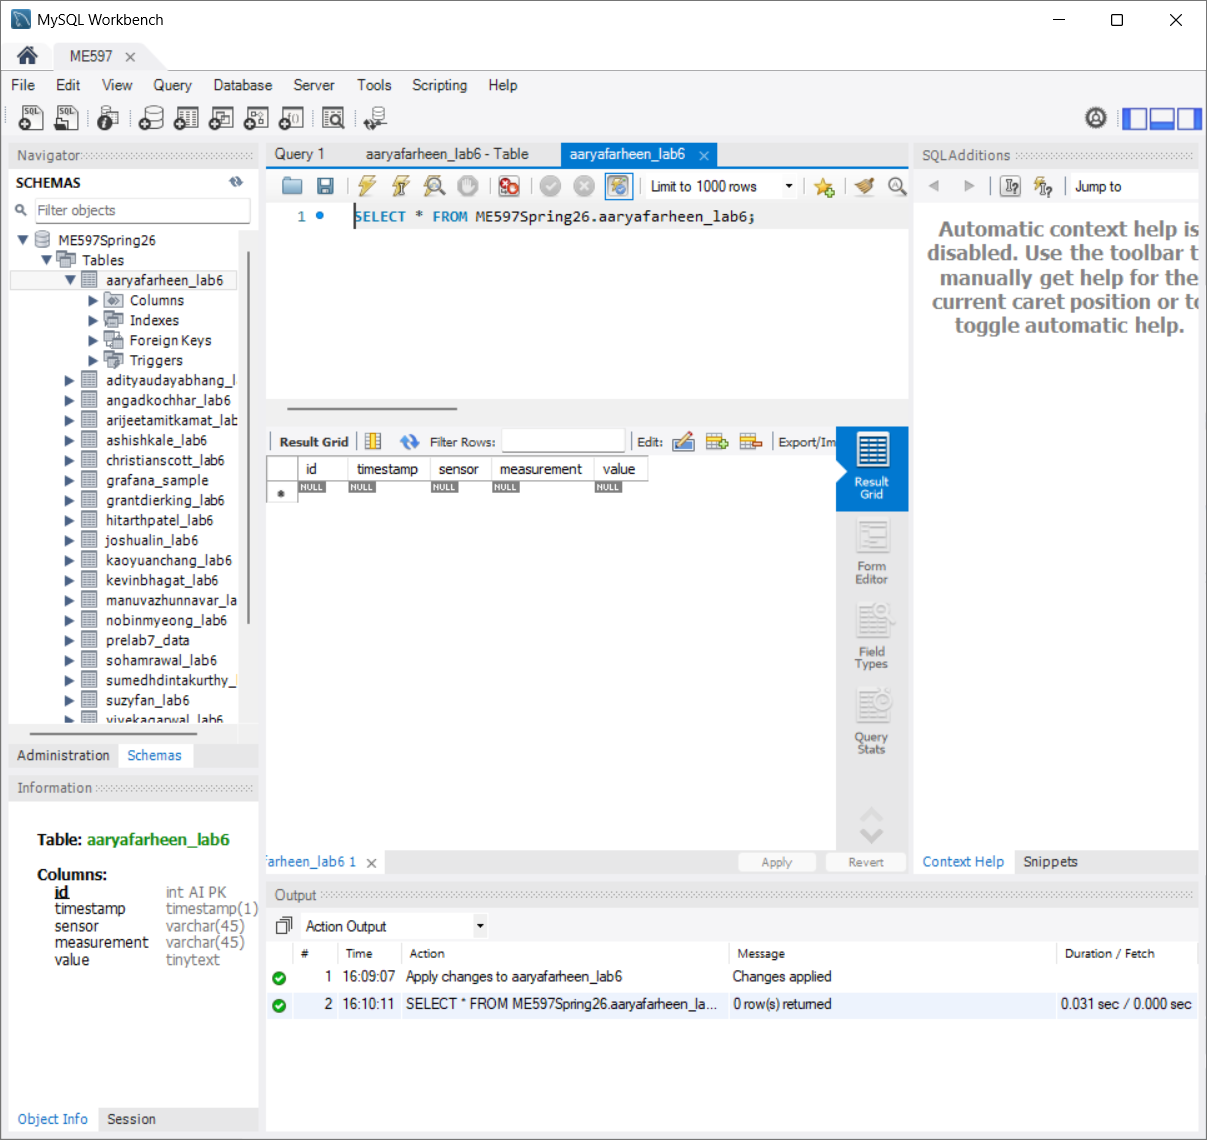

---


## 1.3 SQL query practice

By executing SQL query on ‘MySQL Workbench’, you can manipulate the database. In this part, we will practice only INSERT and SELECT statements to store and see data on the table before we move to Python programming. On the ‘Query’ tab, execute INSERT statement example below. To run the SQL query, click
‘Execute’ icon (lightning bolt) on the menu bar as Figure 2. Please note that you need change the placeholder table name in the sample statement.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_SQL.png?raw=tru" width="40">SQL - INSERT Statement example** - You should check your "database_name" & "yourname_lab6"

```
INSERT INTO database_name.yourname_lab6 (sensor, measurement, value)
VALUES('sensor1','acceleration1','0');
INSERT INTO database_name.yourname_lab6 (sensor, measurement, value)
VALUES('sensor1','acceleration2','3');
INSERT INTO database_name.yourname_lab6 (sensor, measurement, value)
VALUES('sensor2','temperature','25');

```

---

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S24_update/lab6_fig2.png?raw=true" width="70%">

*Figure 2 INSERT statement example*

If you check the table, you see the inserted data as Figure 3. As you see, there is no data in ‘timestamp’ column because we did not include ‘timestamp’ information in the INSERT statement example.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S24_update/lab6_fig3.png?raw=true" width="70%">

*Figure 3 Table after executing INSERT statement example*

Now, let’s try SELECT statement example. The SELECT statement example below is to select only ‘measurement’ and ‘value’ data from ‘sensor1’. The result is shown in Figure 4. Please note that response of SELECT statement is a result grid and ‘*’ after SELECT statement means ‘ALL’.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_SQL.png?raw=tru" width="40">SQL - INSERT Statement example**

```
SELECT measurement, value from database_name.yourname_lab6
WHERE sensor = 'sensor1';

```

---

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S24_update/lab6_fig4.png?raw=true" width="70%">

*Figure 4 Result after executing SELECT statement example*


### Task 1.2

Create a SELECT statement to get ‘timestamp’, ‘measurement’, and ‘value’ data of only ‘sensor’ is ‘sensor2’. Capture the result grid output and attach your SELECT statement and the result as Figure 4 to the report.

---

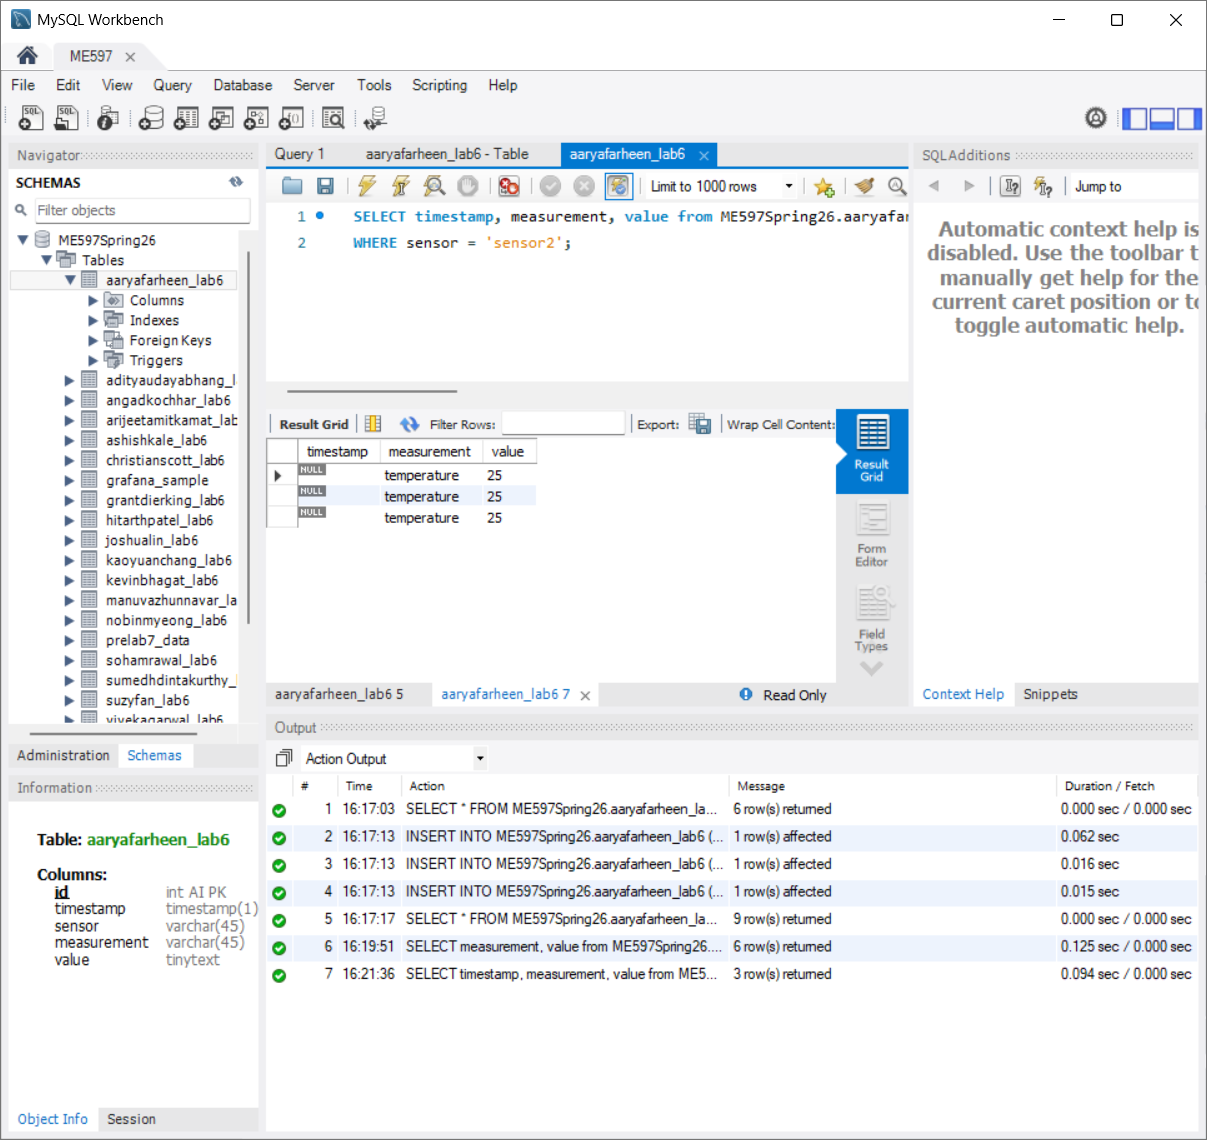

---

In [ ]:
# Place your SQL SELECT statement here.
#
SELECT timestamp, measurement, value from ME597Spring26.aaryafarheen_lab6
WHERE sensor = 'sensor2';

So far, we performed basic use of MySQL. Let’s move to Python programming on Raspberry Pi to collect data.  

<br></br>

Please continue to [Lab 6.2 here](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab6/L6_Colab2.ipynb).
